Dữ liệu: Comment tiếng Việt (từ Google Drive, có nhãn vi phạm).

Tiền xử lý: Chỉ fillna, ép kiểu string. Không tokenize tiếng Việt, không stop words, không teen code, không emoji.

TF‑IDF: ngram_range=(1,2), max_df=0.9, min_df=2.

Mô hình: LogisticRegression với class_weight='balanced'.

Chia tập: 70/15/15, stratify.

Đánh giá: ROC, PR, calibration, CV 5‑fold, FP/FN.

Đặc điểm: Là baseline cho dữ liệu tiếng Việt, chưa xử lý ngôn ngữ.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
    roc_auc_score,
    average_precision_score,
    auc,
    brier_score_loss
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/CommentClassificationDataset/train_full.csv"

data = pd.read_csv(DATA_PATH)
data.head()

Mounted at /content/drive


,comment,is_violation
0,cặc,1.0
1,đr hết thời cày rank bk còn ngợp,0.0
2,Diễn viên hô ni hút mà ngại gì mấy khác kk,0.0
3,Toàn bọn vô công rồi nghề ngồi sủa ăn lương th...,1.0
4,lên kim cương bố ỉa vào mồm mày với cái lối lê...,1.0


In [ ]:
print(data.columns)
print(data.head())

print("\nCount:\n")
print(data["is_violation"].value_counts(dropna=False))

print("\nRatio:\n")
print(data["is_violation"].value_counts(normalize=True, dropna=False))

Index(['comment', 'is_violation'], dtype='object')
                                             comment  is_violation
0                                                cặc           1.0
1                   đr hết thời cày rank bk còn ngợp           0.0
2         Diễn viên hô ni hút mà ngại gì mấy khác kk           0.0
3  Toàn bọn vô công rồi nghề ngồi sủa ăn lương th...           1.0
4  lên kim cương bố ỉa vào mồm mày với cái lối lê...           1.0

Count:

is_violation
1.0    3668
0.0    2684
Name: count, dtype: int64

Ratio:

is_violation
1.0    0.577456
0.0    0.422544
Name: proportion, dtype: float64


In [ ]:
data["comment"] = data["comment"].astype(str).fillna("")
data["is_violation"] = data["is_violation"].astype(int)

X = data["comment"]
y = data["is_violation"]

In [ ]:
# train + temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# val + test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train:", len(X_train))
print("Val  :", len(X_val))
print("Test :", len(X_test))

Train: 4446
Val  : 953
Test : 953


In [ ]:
print("TRAIN ratio:")
print(y_train.value_counts(normalize=True))

print("\nVAL ratio:")
print(y_val.value_counts(normalize=True))

print("\nTEST ratio:")
print(y_test.value_counts(normalize=True))

TRAIN ratio:
is_violation
1    0.577373
0    0.422627
Name: proportion, dtype: float64

VAL ratio:
is_violation
1    0.578174
0    0.421826
Name: proportion, dtype: float64

TEST ratio:
is_violation
1    0.577125
0    0.422875
Name: proportion, dtype: float64


In [ ]:
model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            ngram_range=(1, 2),
            max_df=0.9,
            min_df=2
        )
    ),
    (
        "clf",
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000
        )
    )
])

In [ ]:
model.fit(X_train, y_train)

print("Iterations:", model.named_steps["clf"].n_iter_)

Iterations: [12]


In [ ]:
def find_best_threshold(y_true, y_prob):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)

    precision = precision[:-1]
    recall = recall[:-1]

    f1_scores = (
        2 * precision * recall
        / (precision + recall + 1e-8)
    )

    best_idx = np.argmax(f1_scores)

    return {
        "threshold": thresholds[best_idx],
        "precision": precision[best_idx],
        "recall": recall[best_idx],
        "f1": f1_scores[best_idx]
    }

In [ ]:
y_val_prob = model.predict_proba(X_val)[:, 1]

threshold_info = find_best_threshold(y_val, y_val_prob)
best_threshold = threshold_info["threshold"]

print("Best threshold:", best_threshold)
print("Precision:", threshold_info["precision"])
print("Recall:", threshold_info["recall"])
print("F1:", threshold_info["f1"])

Best threshold: 0.4760200551316738
Precision: 0.8893058161350844
Recall: 0.8602540834845736
F1: 0.8745387403888326


In [ ]:
def evaluate_model(
    model,
    X_split,
    y_true,
    threshold=0.5,
    split_name="DATA"
):
    y_prob = model.predict_proba(X_split)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)

    print(f"\n===== {split_name} =====")
    print(f"ROC-AUC : {roc_auc:.4f}")
    print(f"PR-AUC  : {pr_auc:.4f}")

    print(
        classification_report(
            y_true,
            y_pred,
            digits=4
        )
    )

    print(confusion_matrix(y_true, y_pred))

    return y_prob, y_pred

In [ ]:
y_train_prob, y_train_pred = evaluate_model(
    model,
    X_train,
    y_train,
    threshold=best_threshold,
    split_name="TRAIN"
)

y_val_prob, y_val_pred = evaluate_model(
    model,
    X_val,
    y_val,
    threshold=best_threshold,
    split_name="VALIDATION"
)

y_test_prob, y_test_pred = evaluate_model(
    model,
    X_test,
    y_test,
    threshold=best_threshold,
    split_name="TEST"
)


===== TRAIN =====
ROC-AUC : 0.9851
PR-AUC  : 0.9882
              precision    recall  f1-score   support

           0     0.9281    0.9409    0.9345      1879
           1     0.9563    0.9466    0.9514      2567

    accuracy                         0.9442      4446
   macro avg     0.9422    0.9438    0.9430      4446
weighted avg     0.9444    0.9442    0.9443      4446

[[1768  111]
 [ 137 2430]]

===== VALIDATION =====
ROC-AUC : 0.9273
PR-AUC  : 0.9497
              precision    recall  f1-score   support

           0     0.8167    0.8532    0.8345       402
           1     0.8893    0.8603    0.8745       551

    accuracy                         0.8573       953
   macro avg     0.8530    0.8567    0.8545       953
weighted avg     0.8587    0.8573    0.8577       953

[[343  59]
 [ 77 474]]

===== TEST =====
ROC-AUC : 0.9229
PR-AUC  : 0.9418
              precision    recall  f1-score   support

           0     0.8058    0.8238    0.8147       403
           1     0.8688 

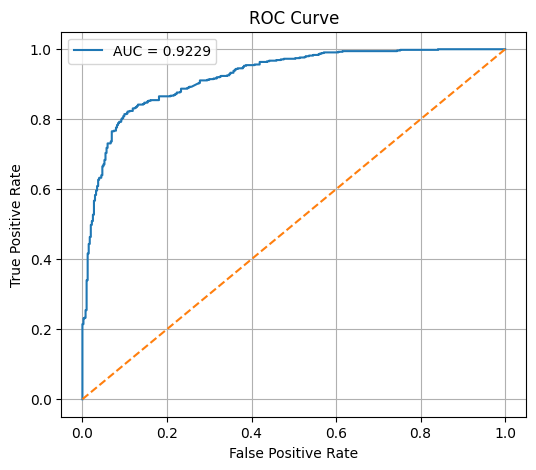

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

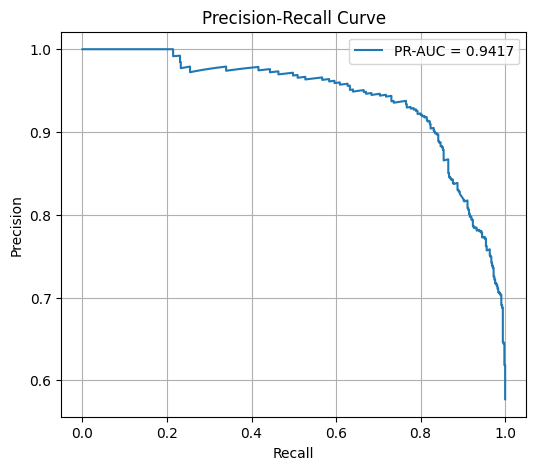

In [ ]:
precision, recall, _ = precision_recall_curve(y_test, y_test_prob)
pr_auc = auc(recall, precision)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

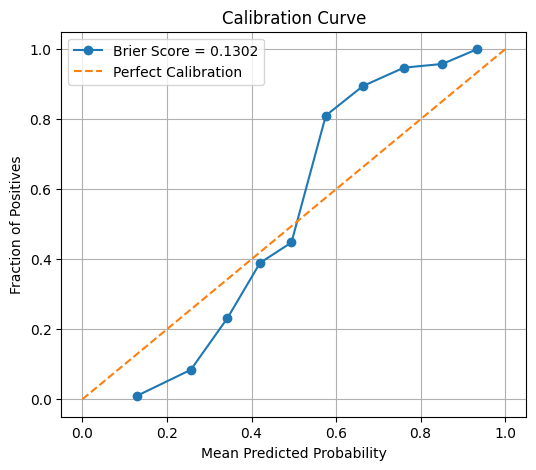

In [ ]:
from sklearn.calibration import calibration_curve

frac_pos, mean_pred = calibration_curve(
    y_test,
    y_test_prob,
    n_bins=10,
    strategy="quantile"
)

brier = brier_score_loss(y_test, y_test_prob)

plt.figure(figsize=(6, 5))
plt.plot(
    mean_pred,
    frac_pos,
    marker="o",
    label=f"Brier Score = {brier:.4f}"
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
cv_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            ngram_range=(1, 2),
            max_df=0.9,
            min_df=2
        )
    ),
    (
        "clf",
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000
        )
    )
])

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_validate(
    cv_model,
    X_train,
    y_train,
    cv=skf,
    scoring={
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc",
        "pr_auc": "average_precision"
    },
    return_train_score=False,
    n_jobs=-1
)

In [ ]:
for metric in cv_scores:
    if metric.startswith("test_"):
        vals = cv_scores[metric]
        print(
            f"{metric}: "
            f"{vals.mean():.4f} "
            f"+/- "
            f"{vals.std():.4f}"
        )

test_accuracy: 0.8412 +/- 0.0113
test_precision: 0.8838 +/- 0.0160
test_recall: 0.8352 +/- 0.0216
test_f1: 0.8585 +/- 0.0110
test_roc_auc: 0.9202 +/- 0.0086
test_pr_auc: 0.9392 +/- 0.0083


In [ ]:
def show_fp_fn_samples(
    X_split,
    y_true,
    y_pred,
    y_prob,
    n=10
):
    df = pd.DataFrame({
        "comment": X_split.values,
        "true_label": y_true.values,
        "pred_label": y_pred,
        "prob_violation": y_prob
    })

    fp = df[
        (df["true_label"] == 0) &
        (df["pred_label"] == 1)
    ]

    fn = df[
        (df["true_label"] == 1) &
        (df["pred_label"] == 0)
    ]

    print("\n===== FALSE POSITIVES =====")
    print(
        fp.sort_values("prob_violation", ascending=False)
          .head(n)[["prob_violation", "comment"]]
    )

    print("\n===== FALSE NEGATIVES =====")
    print(
        fn.sort_values("prob_violation", ascending=True)
          .head(n)[["prob_violation", "comment"]]
    )

In [ ]:
show_fp_fn_samples(
    X_test,
    y_test,
    y_test_pred,
    y_test_prob,
    n=10
)


===== FALSE POSITIVES =====
     prob_violation                                            comment
860        0.874018              Mấy thằng hàn nó k sang nó vả cho nhỉ
310        0.866518  Mày coi lại não mày load hết được cmt tao chưa...
93         0.866447  Mai Hà vậy mày coi lại bình luận đầu tiên của ...
48         0.854769                Con chó nó ngửi được mùi thằng trộm
893        0.806158                                    cái tay cái tay
739        0.767158  Xin đừng tin ai ở cái xã hội này-lừa đảo , cướ...
170        0.749957                               Mày nghĩ xl là hết à
401        0.734598      Con chó nó phản ứng là hiểu rồi, nên đề phòng
349        0.718226                    Đúng là gọi tên con ngáo mà kkk
830        0.712610  Xin lỗi mà bắt như gì vậy á bắt ko bằng mấy tr...

===== FALSE NEGATIVES =====
     prob_violation                                            comment
418        0.168347  r, hiểu r, bạn là dlv :)) thôi mình out, k nói...
145        0.218439